In [61]:
%reload_ext autoreload
%autoreload 2

In [62]:
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
from collections import OrderedDict

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(PROJECT_ROOT)
sys.path.append("/cluster/home/herminea/mental_health_project/workspace/utils")
sys.path.append("/cluster/home/herminea/mental_health_project/workspace/scripts")

from utils.io.io_results import load_fc_results, group_results_by_subject, load_fc_combined_data
from utils.functional_connectivity.fc_compute import bin_fcs_by_freq
from utils.functional_connectivity.fc_aggregate_network import aggregate_to_network_fc
from utils.functional_connectivity.fc_matrix_analysis import (
    analyze_similarity_by_imf,
    compute_similarity_matrix,
    group_similarity_means,
    permutation_test_within_vs_between,
)
from utils.plot.plot_base import set_mpl_style
from utils.plot.plot_fc import plot_fc_subject, plot_fc_subject_combined
from utils.plot.plot_decomp import plot_example_subjects
from utils.plot.plot_summary import (
    plot_similarity_by_imf,
    plot_similarity_by_band,
    plot_imf_frequency_distribution,
)

sns.set_theme(context="paper", style="white", font_scale=1.0)
set_mpl_style()

In [63]:
METHOD           = "vlmd"
RES_DIR          = f"/cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/{METHOD}/fc"
COMBINED_RES_DIR = f"/cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/{METHOD}/combined_fc"
ATLAS_PATH       = "/cluster/home/herminea/mental_health_project/workspace/atlas/roi_to_net_434.csv"
FIG_DIR          = "/cluster/home/herminea/mental_health_project/workspace/fmri_notebooks/analysis/results/figures" 

---
## Section 1: Individual Subject FC Visualization

In [64]:
# Load run-level FC results (one entry per subject per run)
results       = load_fc_results(RES_DIR)
subjects_dict = group_results_by_subject(results)
print(f"Loaded {len(results)} run-level FC files from {len(subjects_dict)} subjects")

[Load] Loaded 165 FC result files from /cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/vlmd/fc
Loaded 165 run-level FC files from 42 subjects


In [65]:
# Plot ROI-level FC matrices for one MDD and one HC subject
SAVE_DIR = os.path.join(FIG_DIR, "fc_subjects")

mdd_subjects = [s for s, runs in subjects_dict.items() if runs[0]["group"] == "MDD"]
hc_subjects  = [s for s, runs in subjects_dict.items() if runs[0]["group"] == "HC"]

subjects_to_plot = mdd_subjects[:1] + hc_subjects[:1]

# for subj_id in subjects_to_plot:
#     plot_fc_subject(subj_id, subjects_dict, include_wholeband=True, plot_space="r")
#     plot_fc_subject_combined(
#         subj_id, subjects_dict, include_wholeband=True,
#         save_dir=SAVE_DIR, plot_space="r",
#     )

---
## Section 2: Frequency-Binned and Network-Aggregated FC

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — FREQUENCY-BINNED AND NETWORK-AGGREGATED FC
# ─────────────────────────────────────────────────────────────────────────────

# Load combined (run-averaged) FC data
subjects_combined, fcs_by_imf, groups, freqs_by_imf = load_fc_combined_data(COMBINED_RES_DIR)
print(f"Loaded combined FC for {len(subjects_combined)} subjects: "
      f"{sum(g == 'MDD' for g in groups.values())} MDD, "
      f"{sum(g == 'HC' for g in groups.values())} HC")

[Load] Loaded 42 FC result files from /cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/vlmd/combined_fc
Loaded combined FC for 42 subjects: 21 MDD, 21 HC


In [67]:
# Bin IMF-level FCs by frequency band
freq_bands = {
    "Slow-5": (0.01, 0.027),
    "Slow-4": (0.027, 0.073),
    "Slow-3": (0.073, 0.198),
    "Slow-2": (0.198, 0.25),
}
fcs_by_band = bin_fcs_by_freq(subjects_combined, freq_bands)
fcs_by_band["Whole"] = {s: fcs_by_imf["whole"][s] for s in fcs_by_imf["whole"]}
fcs_by_band = OrderedDict(
    (k, fcs_by_band[k])
    for k in ["Whole", "Slow-5", "Slow-4", "Slow-3", "Slow-2"]
    if k in fcs_by_band
)

# Load atlas and aggregate ROI-level FCs to network level
atlas_df = pd.read_csv(ATLAS_PATH)
atlas_df["NetworkID"]   = pd.to_numeric(atlas_df["NetworkID"], errors="coerce").astype(int)
atlas_df["NetworkName"] = atlas_df["NetworkName"].astype(str)
roi_to_net   = atlas_df["NetworkID"].values
n_networks   = len(__import__("numpy").unique(roi_to_net))
net_names_21 = atlas_df.groupby("NetworkID")["NetworkName"].first().to_list()

binned_netfcs = {
    band: {
        s: aggregate_to_network_fc(fc, roi_to_net, n_networks)
        for s, fc in subj_dict.items()
    }
    for band, subj_dict in fcs_by_band.items()
}

In [68]:
# Plot network-level FC matrices for one MDD subject
mdd_subjects = [s for s, g in groups.items() if g == "MDD"]

for idx, s in enumerate(mdd_subjects[:1], start=1):
    path = os.path.join(COMBINED_RES_DIR, f"{s}_combined_fc.pkl")
    with open(path, "rb") as f:
        subj_data = pickle.load(f)

    agg_fc_modes = [
        aggregate_to_network_fc(fc, roi_to_net, n_networks)
        for fc in subj_data["fc_modes"]
    ]
    agg_fc_whole = aggregate_to_network_fc(
        subj_data["fc_whole"], roi_to_net, n_networks
    )
    subj_data["fc_net"]       = __import__("numpy").stack(agg_fc_modes, axis=0)
    subj_data["fc_whole_net"] = agg_fc_whole

    plot_fc_subject_combined(
        s, {s: subj_data},
        subj_display=f"Subject {idx:02d}",
        use_network=True,
        show_sparse_ticks=True,
        ticks_on="all",
        save=True,
    )

Saved results/figures/fc_subjects/NDAR_INVBL733HBP_MDD_net_combined_fc.pdf


---
## Section 3: FC Similarity Analysis

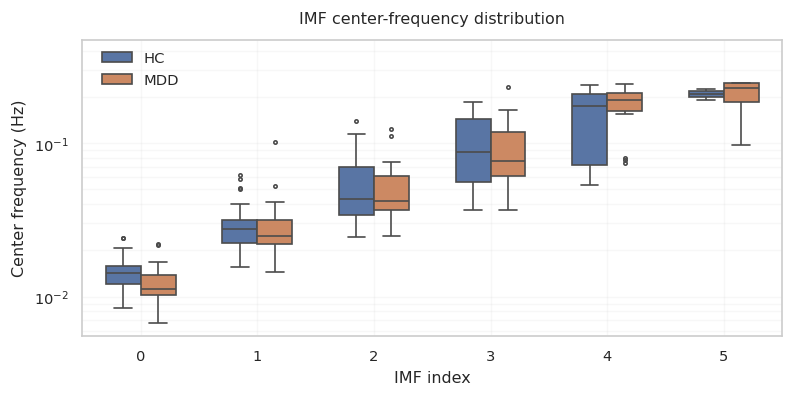

(<Figure size 780x384 with 1 Axes>,
 <Axes: title={'center': 'IMF center-frequency distribution'}, xlabel='IMF index', ylabel='Center frequency (Hz)'>)

In [69]:
# IMF frequency distribution across subjects and groups
all_freqs  = []
all_labels = []
for subj, entry in subjects_combined.items():
    freqs = entry[0]["freqs"]
    group = entry[0]["group"]
    for i, f in enumerate(freqs, start=1):
        all_freqs.append(f)
        all_labels.append((group, i - 1))

df_freqs = pd.DataFrame(all_labels, columns=["Group", "IMF"])
df_freqs["Frequency"] = all_freqs

plot_imf_frequency_distribution(
    df_freqs,
    outpath_no_ext=os.path.join(FIG_DIR, "mfc_analysis", "imf_frequency_boxplot"),
)

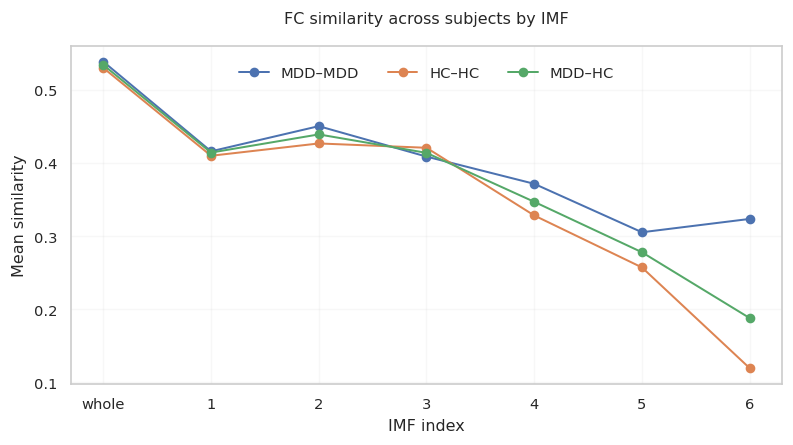

(<Figure size 780x432 with 1 Axes>,
 <Axes: title={'center': 'FC similarity across subjects by IMF'}, xlabel='IMF index', ylabel='Mean similarity'>)

In [70]:
# Within-group vs between-group FC similarity per IMF
summary_imf = analyze_similarity_by_imf(fcs_by_imf, groups)
summary_imf["IMF"] = summary_imf["IMF"].astype(str)

plot_similarity_by_imf(
    summary_imf,
    outpath_no_ext=os.path.join(FIG_DIR, "mfc_analysis", "similarity_by_imf"),
)

  Band  MDD-MDD  HC-HC  MDD-HC   delta      p
 Whole   0.5384 0.5299  0.5339  0.0002 0.9464
Slow-5   0.4836 0.4472  0.4651 -0.0006 0.8632
Slow-4   0.4641 0.4673  0.4673 -0.0015 0.6500
Slow-3   0.3582 0.3654  0.3602  0.0009 0.8708
Slow-2   0.3130 0.1616  0.2222  0.0509 0.0132


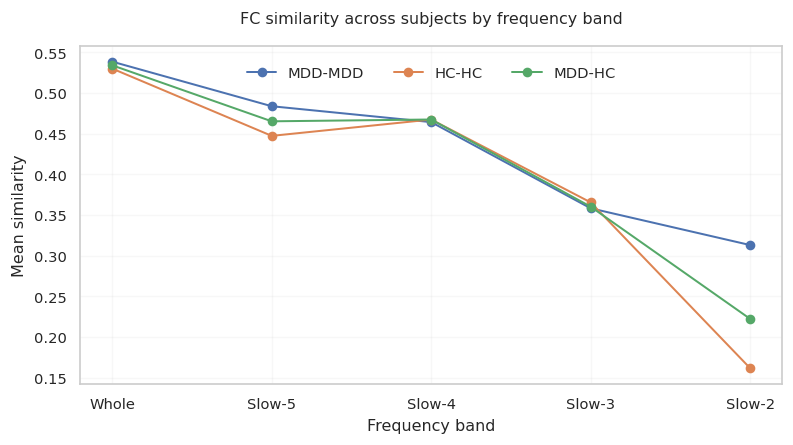

(<Figure size 780x432 with 1 Axes>,
 <Axes: title={'center': 'FC similarity across subjects by frequency band'}, xlabel='Frequency band', ylabel='Mean similarity'>)

In [71]:
# Within-group vs between-group FC similarity per frequency band
summary_band = []
for band, fcs in fcs_by_band.items():
    sim, subs = compute_similarity_matrix(fcs)
    MDD_MDD, HC_HC, MDD_HC = group_similarity_means(sim, subs, groups)
    diff, pval = permutation_test_within_vs_between(sim, subs, groups)
    summary_band.append((band, MDD_MDD, HC_HC, MDD_HC, diff, pval))

summary_band = pd.DataFrame(
    summary_band, columns=["Band", "MDD-MDD", "HC-HC", "MDD-HC", "delta", "p"]
)
print(summary_band.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

plot_similarity_by_band(
    summary_band,
    outpath_no_ext=os.path.join(FIG_DIR, "mfc_analysis", "similarity_by_band"),
)